In [2]:
%pip install scikit-plot
%pip install tensorflow
%pip install scipy==1.9.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 784.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.4/33.4 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
imbalanced-learn 0.13.0 requires scipy<2,>=1.10.1, but you have scipy 1.9.3 which is incompatible.
cvxpy 1.6.4 requires scipy>=1.11.0, but you have scipy 1.9.3 which is incompatible.
blosc


# Uploading Data

In [1]:
# Importing needed libraries

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import scikitplot as skplt

import tensorflow as tf
from sklearn import svm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report,accuracy_score

import warnings
import csv
import random

In [2]:
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Loading dataset
df = pd.read_csv('ObesityDataSet.csv')

In [4]:
# Saving the numeric columns
numerical_features = ['Age','Height','Weight']

In [5]:
# Applying label encoding
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# Data Visualization

Correlation between CH2O and Weight: 0.20
Correlation Table:
            CH2O    Weight
CH2O    1.000000  0.200575
Weight  0.200575  1.000000


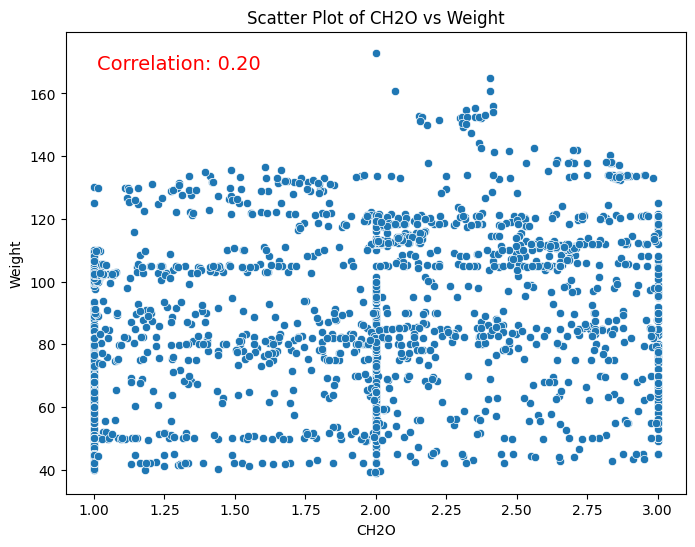

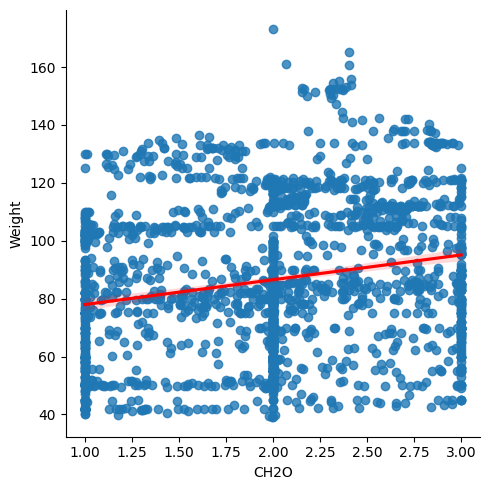

In [48]:
#we will analyze CH20 and weight:
feature_1 = 'CH2O'
feature_2 = 'Weight'


#finding the corr btw CH20 and weight:
correlation = df[[feature_1, feature_2]].corr().iloc[0, 1]
print(f"Correlation between {feature_1} and {feature_2}: {correlation:.2f}")

#creating a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[feature_1], y=df[feature_2])
plt.title(f'Scatter Plot of {feature_1} vs {feature_2}')
plt.xlabel(feature_1)
plt.ylabel(feature_2)

plt.text(0.05, 0.95, f'Correlation: {correlation:.2f}', transform=plt.gca().transAxes, fontsize=14, color='red', verticalalignment='top')

#finding the corr matrix:
correlation_matrix = df[[feature_1, feature_2]].corr()

print("Correlation Table:")
print(correlation_matrix)
sns.lmplot(x=feature_1, y=feature_2, data=df, line_kws={"color": "red"})

plt.show()



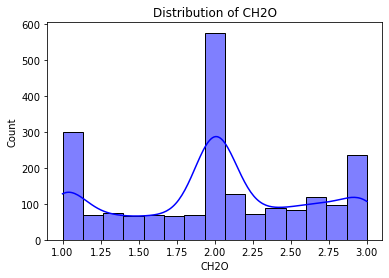

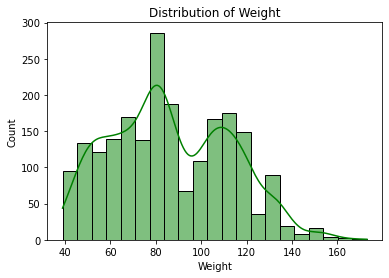

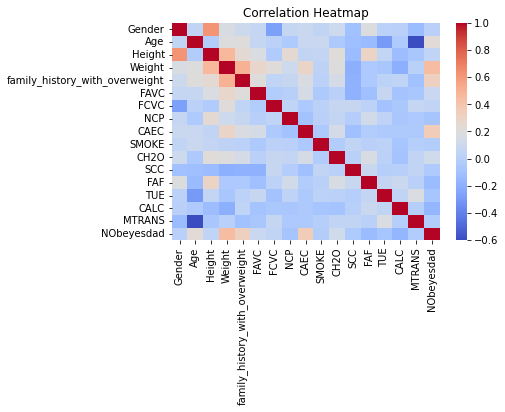

In [ ]:
#histogram for CH20:
sns.histplot(df[feature_1], kde=True, color='blue')
plt.title(f'Distribution of {feature_1}')
plt.show()

#histogram for weight:
sns.histplot(df[feature_2], kde=True, color='green')
plt.title(f'Distribution of {feature_2}')
plt.show()

#heatmap:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

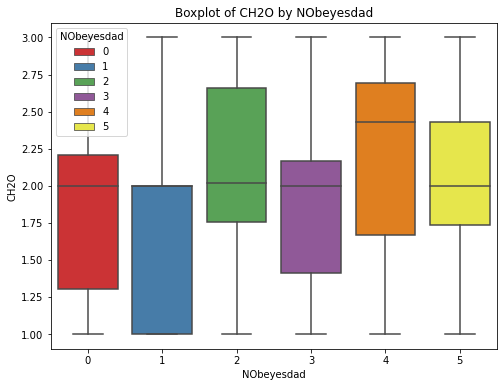

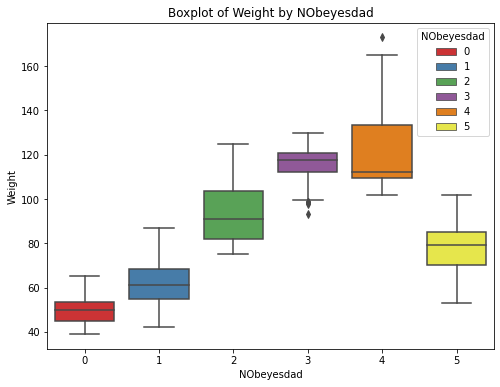

In [ ]:
class_column = 'NObeyesdad'

#CH20 vs classes:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df[class_column], y=df[feature_1],  hue=df[class_column], dodge=False, palette="Set1")
plt.title(f'Boxplot of {feature_1} by {class_column}')
plt.xlabel(class_column)
plt.ylabel(feature_1)
plt.show()

#weight vs classes:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df[class_column], y=df[feature_2], hue=df[class_column], dodge=False, palette="Set1")
plt.title(f'Boxplot of {feature_2} by {class_column}')
plt.xlabel(class_column)
plt.ylabel(feature_2)
plt.show()



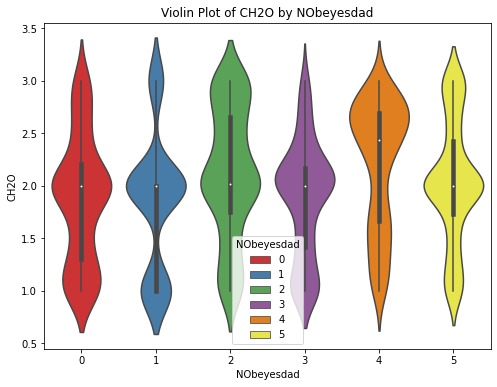

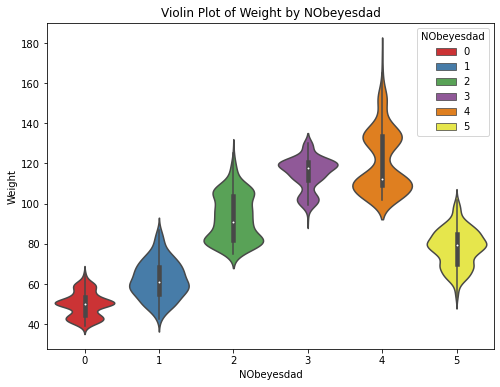

In [ ]:
#repeating with violin plots:
plt.figure(figsize=(8, 6))
sns.violinplot(x=df[class_column], y=df[feature_1],  hue=df[class_column], dodge=False, palette="Set1")
plt.title(f'Violin Plot of {feature_1} by {class_column}')
plt.xlabel(class_column)
plt.ylabel(feature_1)
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x=df[class_column], y=df[feature_2], hue=df[class_column], dodge=False, palette="Set1")
plt.title(f'Violin Plot of {feature_2} by {class_column}')
plt.xlabel(class_column)
plt.ylabel(feature_2)
plt.show()

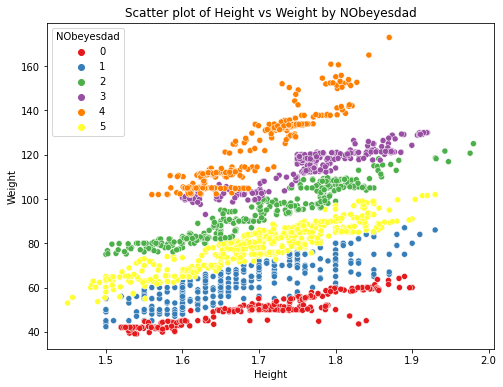

In [ ]:
#scatter plot:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Height',
    y=feature_2,
    hue=class_column,
    data=df,
    palette="Set1"
)

plt.title(f'Scatter plot of Height vs {feature_2} by {class_column}')
plt.show()

# Preparation

In [6]:
#seperating features from classes
X_unscaled = df.drop('NObeyesdad', axis=1)  # Feature set
y = df['NObeyesdad']               # Target variable
feature_names = X_unscaled.columns

#Scaling and splitting
scaler = StandardScaler()
X = scaler.fit_transform(X_unscaled[['Height', 'Weight']])
feature_names2 = ['Height', 'Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X_unscaled, y, test_size=0.2, stratify=y, random_state=42)

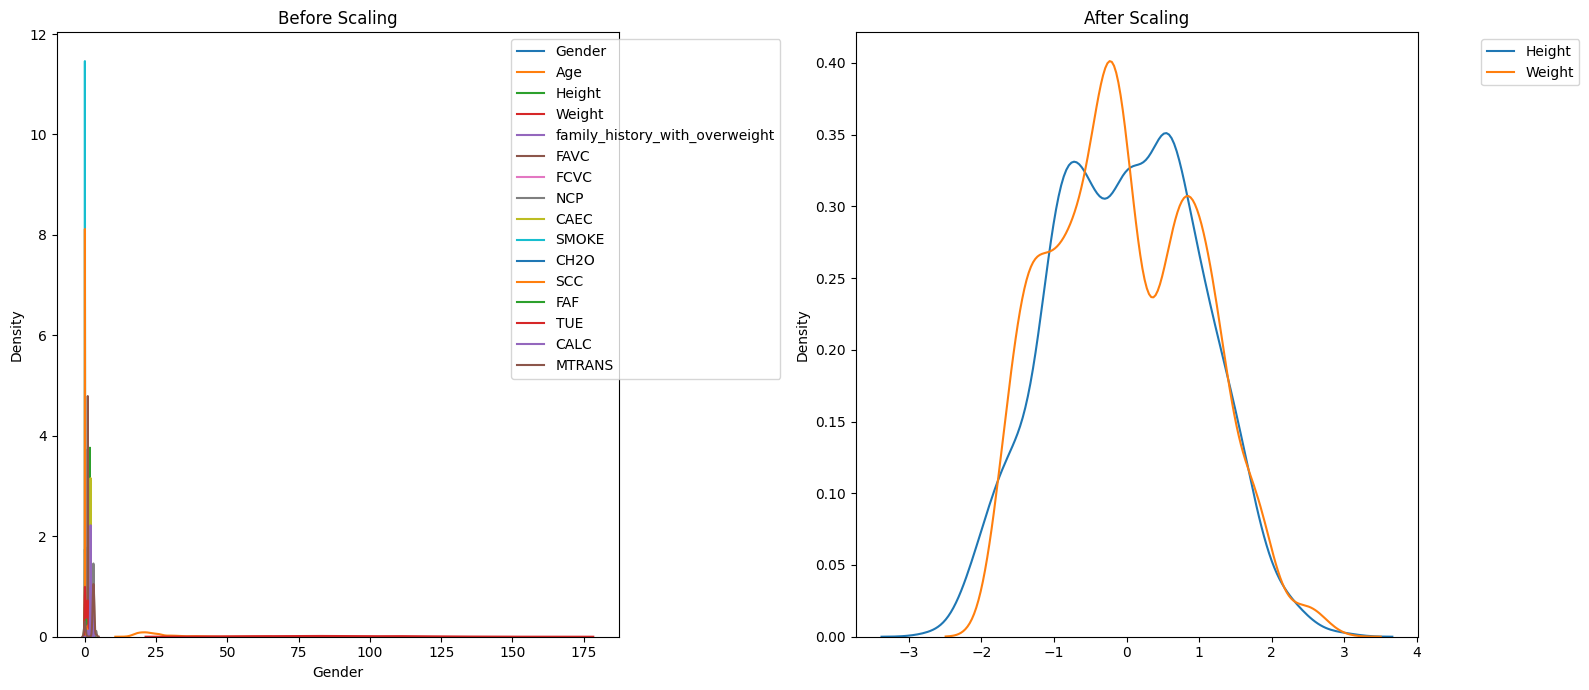

In [7]:
# Plotting data before & after scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Before Scaling
for i in range(X_train_unscaled.shape[1]):
    sns.kdeplot(X_train_unscaled.iloc[:, i], ax=axes[0], label=feature_names[i])

axes[0].set_title('Before Scaling')
axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# After Scaling
for i in range(X_train.shape[1]):
    sns.kdeplot(X_train[:, i], ax=axes[1], label=feature_names2[i])

axes[1].set_title('After Scaling')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1))

plt.tight_layout()
plt.show()

# KNN

In [8]:
# Innetiating KKN model
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [9]:
# Evaluating the model
y_pred = knn.predict(X_test)
conf_m = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", conf_m)


Accuracy: 0.9716312056737588

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        54
           1       0.96      0.91      0.94        58
           2       0.97      0.99      0.98        70
           3       0.97      0.95      0.96        60
           4       0.98      0.98      0.98        65
           5       0.99      0.98      0.99       116

    accuracy                           0.97       423
   macro avg       0.97      0.97      0.97       423
weighted avg       0.97      0.97      0.97       423


Confusion Matrix:
 [[ 54   0   0   0   0   0]
 [  4  53   0   0   0   1]
 [  0   0  69   1   0   0]
 [  0   0   2  57   1   0]
 [  0   0   0   1  64   0]
 [  0   2   0   0   0 114]]


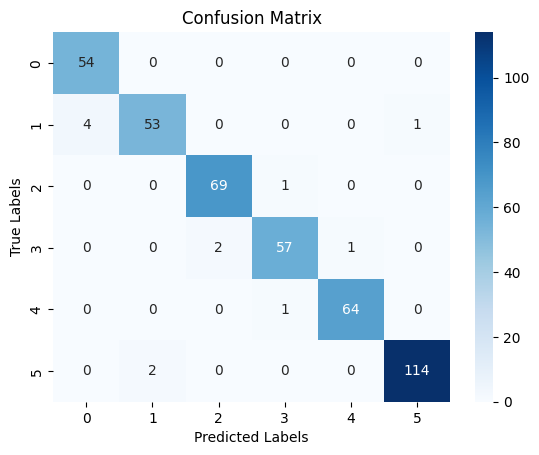

In [10]:
# Plotting Confusion Matrix
sns.heatmap(conf_m , annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Cross-Validation using K-fold
kf = KFold(n_splits=10, shuffle=True, random_state=33) #10 folds is standard
scores = cross_val_score(knn, X_train, y_train, cv=kf)

for score in scores:
    print('Fold Accuracy:', score)

Fold Accuracy: 0.9704142011834319
Fold Accuracy: 0.9526627218934911
Fold Accuracy: 0.9822485207100592
Fold Accuracy: 0.9526627218934911
Fold Accuracy: 0.9881656804733728
Fold Accuracy: 0.9763313609467456
Fold Accuracy: 0.9349112426035503
Fold Accuracy: 0.9408284023668639
Fold Accuracy: 0.9345238095238095
Fold Accuracy: 0.9702380952380952


In [12]:
# Predicting a random test data
i = random.randint(0, X_test.shape[0] - 1)
sample = X_test[[i]]
predicted_class = knn.predict(sample)
decoded_class = label_encoder.inverse_transform(predicted_class)
print("Predicted Class:", decoded_class[0])
print("Actual Class",  label_encoder.inverse_transform([y_test.iloc[i]]))

Predicted Class: Overweight
Actual Class ['Overweight']


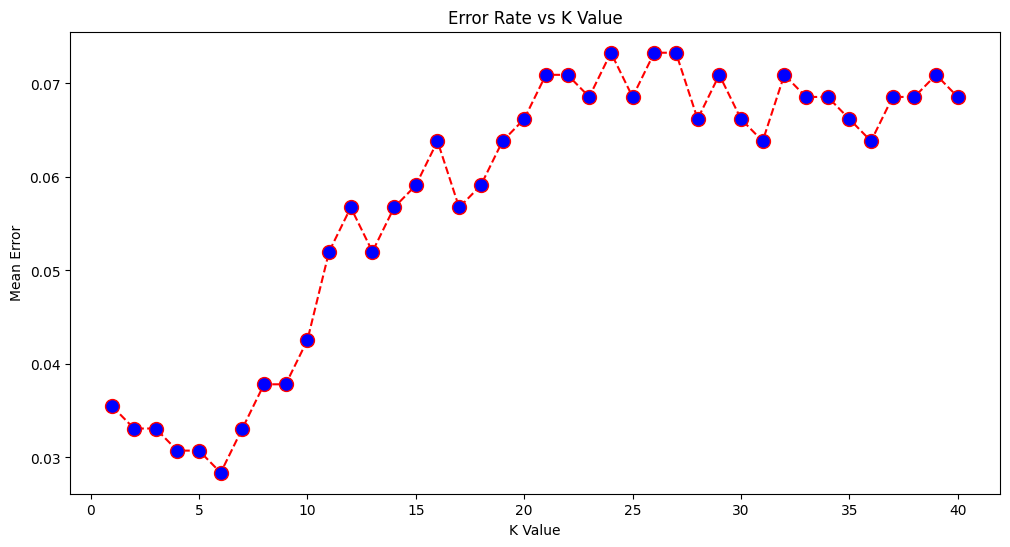

In [13]:
# Plotting the error function for different Ks

error = []

# Trying K from 1 to 40
for k in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error.append(np.mean(pred_k != y_test))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(range(1, 41), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')
plt.show()


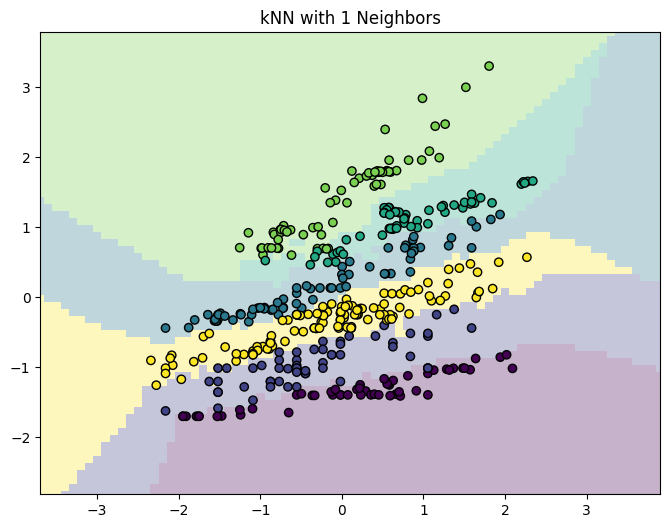

Classification error for k=1: 0.0355


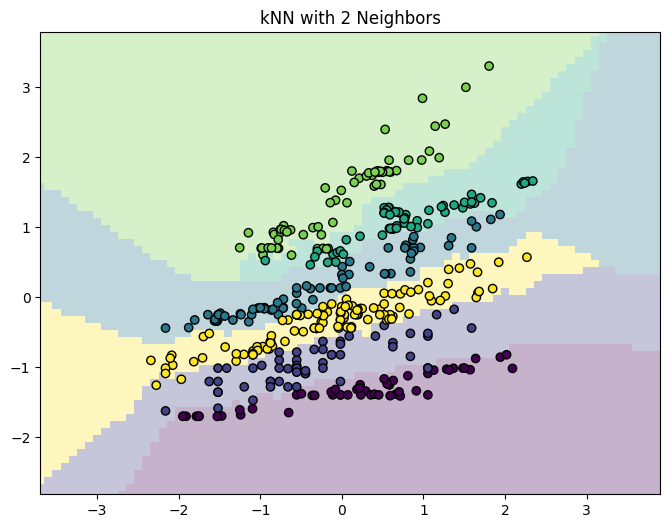

Classification error for k=2: 0.0331


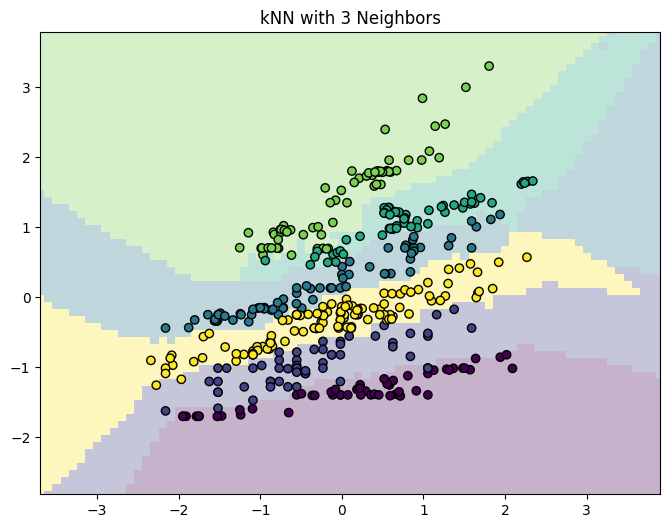

Classification error for k=3: 0.0331


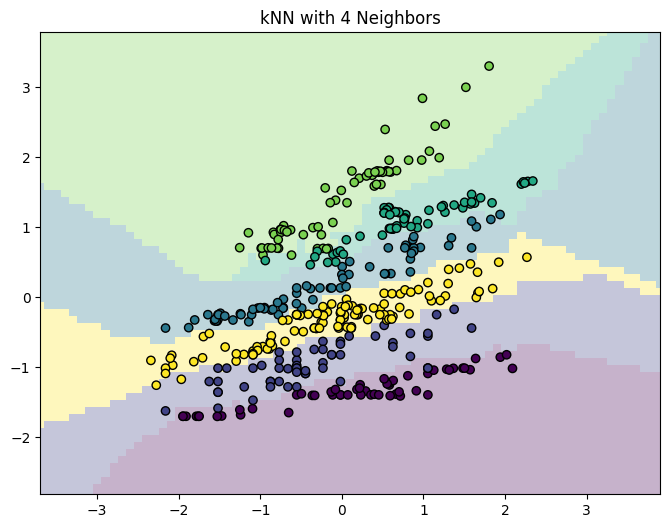

Classification error for k=4: 0.0307


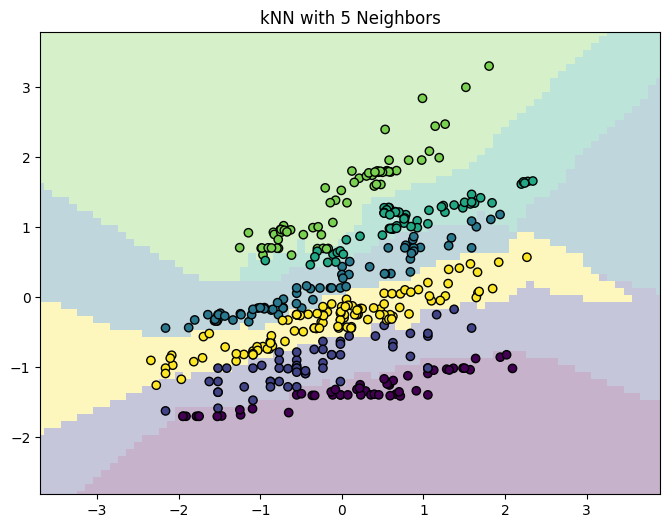

Classification error for k=5: 0.0307


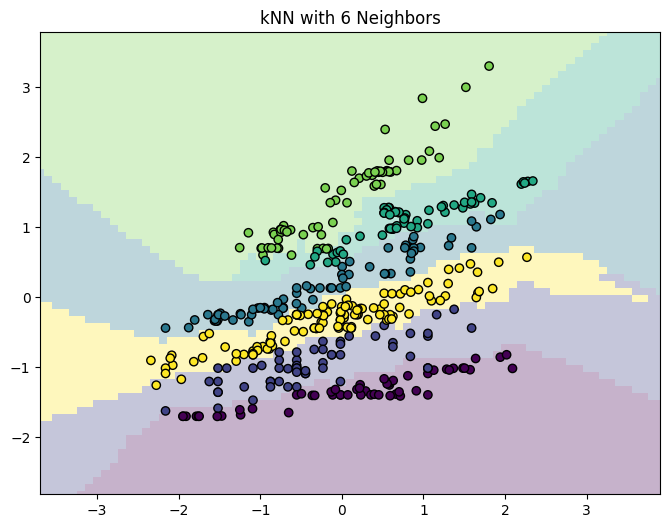

Classification error for k=6: 0.0284


In [14]:
# Plotting decision boundaries with different Ks

def decision_boundary(X_train, y_train, X_test, y_test, model, grid_size=0.1):
    # Accessing data using NumPy indexing
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_size),
                         np.arange(y_min, y_max, grid_size))

    # Creating a DataFrame for prediction, ensuring column names match
    pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
    pred = pred.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, pred, alpha=0.3)

    # Accessing data using NumPy indexing for scatter plot
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k')
    plt.title(f'kNN with {model.n_neighbors} Neighbors')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


# K = [1:6]
for k in [1,2,3,4,5,6]:
    knn2 = KNeighborsClassifier(n_neighbors=k)
    knn2.fit(X_train, y_train)
    decision_boundary(X_train, y_train, X_test, y_test, knn2)
    error = 1 - knn2.score(X_test, y_test)
    print(f"Classification error for k={k}: {error:.4f}")

# SVM

### Train and test the model with different kernels
To find which kernel performs best we will test the accuracy of 3 kernel types through their confusion matrices

#### 1. Linear Kernel

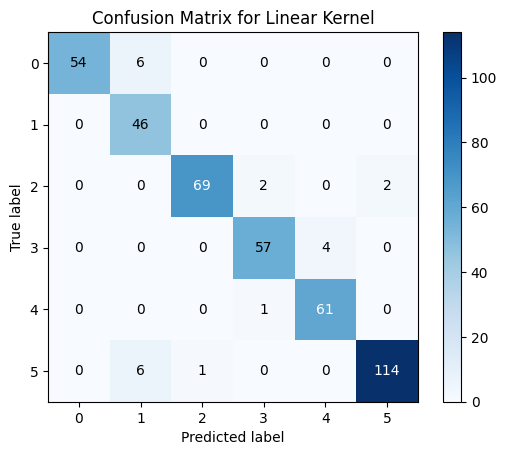

Linear SVM Accuracy:  0.9479905437352246

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        54
           1       1.00      0.79      0.88        58
           2       0.95      0.99      0.97        70
           3       0.93      0.95      0.94        60
           4       0.98      0.94      0.96        65
           5       0.94      0.98      0.96       116

    accuracy                           0.95       423
   macro avg       0.95      0.94      0.94       423
weighted avg       0.95      0.95      0.95       423


Confusion Matrix:
 [[ 54   0   0   0   0   0]
 [  4  53   0   0   0   1]
 [  0   0  69   1   0   0]
 [  0   0   2  57   1   0]
 [  0   0   0   1  64   0]
 [  0   2   0   0   0 114]]


In [19]:
# Linear kernel
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

skplt.metrics.plot_confusion_matrix(y_pred,y_test,  normalize=False, title="Confusion Matrix for Linear Kernel")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Linear SVM Accuracy: ",accuracy)

# Displaying classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", conf_m)

#### 2. RBF Kernel

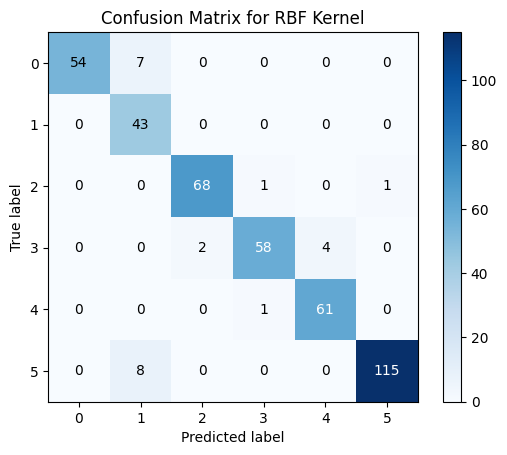

RBF SVM Accuracy:  0.9432624113475178

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94        54
           1       1.00      0.74      0.85        58
           2       0.97      0.97      0.97        70
           3       0.91      0.97      0.94        60
           4       0.98      0.94      0.96        65
           5       0.93      0.99      0.96       116

    accuracy                           0.94       423
   macro avg       0.95      0.93      0.94       423
weighted avg       0.95      0.94      0.94       423


Confusion Matrix:
 [[ 54   0   0   0   0   0]
 [  4  53   0   0   0   1]
 [  0   0  69   1   0   0]
 [  0   0   2  57   1   0]
 [  0   0   0   1  64   0]
 [  0   2   0   0   0 114]]


In [20]:
#RBF kernel
RBF_model = svm.SVC(kernel='rbf')
RBF_model.fit(X_train, y_train)
y_pred = RBF_model.predict(X_test)

skplt.metrics.plot_confusion_matrix(y_pred,y_test,  normalize=False, title="Confusion Matrix for RBF Kernel")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("RBF SVM Accuracy: ",accuracy)

# Displaying classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", conf_m)

#### 3. Polynomial Kernel

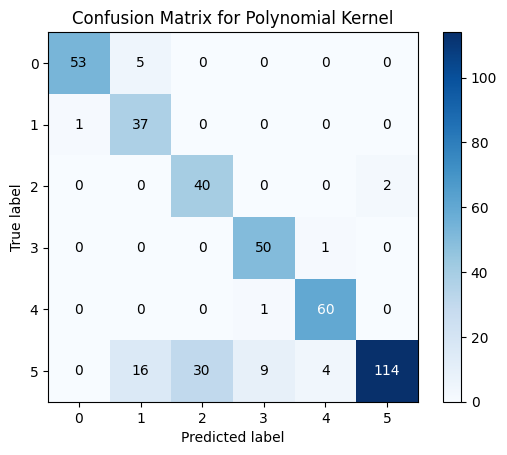

Polynomial SVM Accuracy:  0.8368794326241135

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95        54
           1       0.97      0.64      0.77        58
           2       0.95      0.57      0.71        70
           3       0.98      0.83      0.90        60
           4       0.98      0.92      0.95        65
           5       0.66      0.98      0.79       116

    accuracy                           0.84       423
   macro avg       0.91      0.82      0.85       423
weighted avg       0.88      0.84      0.84       423


Confusion Matrix:
 [[ 54   0   0   0   0   0]
 [  4  53   0   0   0   1]
 [  0   0  69   1   0   0]
 [  0   0   2  57   1   0]
 [  0   0   0   1  64   0]
 [  0   2   0   0   0 114]]


In [21]:
# Polynomial kernel
polynomial_model = svm.SVC(kernel='poly')
polynomial_model.fit(X_train, y_train)
y_pred = polynomial_model.predict(X_test)

skplt.metrics.plot_confusion_matrix(y_pred,y_test,  normalize=False, title="Confusion Matrix for Polynomial Kernel")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Polynomial SVM Accuracy: ",accuracy)

# Displaying classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", conf_m)

### Implementing k-folds cross validation on linear SVM¶

Since the linear kernel showed the best results that is the kernel that will be chosen for the SVM models shown below.

In [38]:
# Cross Validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(linear_model, X, y, cv=kf)

for score in scores:
    print('Fold accuracy:',score)

Fold accuracy: 0.9339622641509434
Fold accuracy: 0.9715639810426541
Fold accuracy: 0.9241706161137441
Fold accuracy: 0.933649289099526
Fold accuracy: 0.9478672985781991
Fold accuracy: 0.9478672985781991
Fold accuracy: 0.9289099526066351
Fold accuracy: 0.9715639810426541
Fold accuracy: 0.933649289099526
Fold accuracy: 0.957345971563981


### Plotting support vectors and decision boundaries

In [39]:
#Using get dummies to turn the multiclass classification into binary
#it will work by taking one class vs the rest and this is automatically done in the SVM implementation
df2 = pd.read_csv('ObesityDataSet.csv')
df2 = pd.get_dummies(df2, columns=['NObeyesdad'])
df2[numerical_features] = scaler.fit_transform(df2[numerical_features])

#only the first and last classes will work with a simple linear kernel so i will display them
#the middle classes will require projection onto a higher dimensional space before being grouped into
#1 class vs the rest of the classes
classes = ['NObeyesdad_Insufficient_Weight', 'NObeyesdad_Obesity_Type_III']

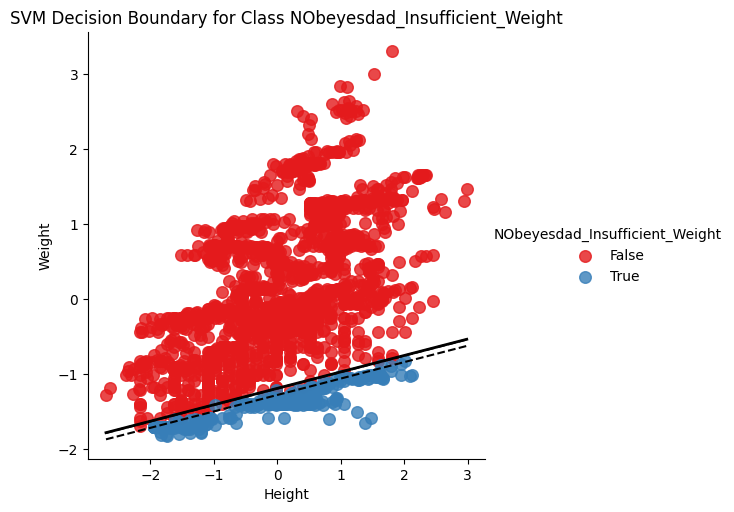

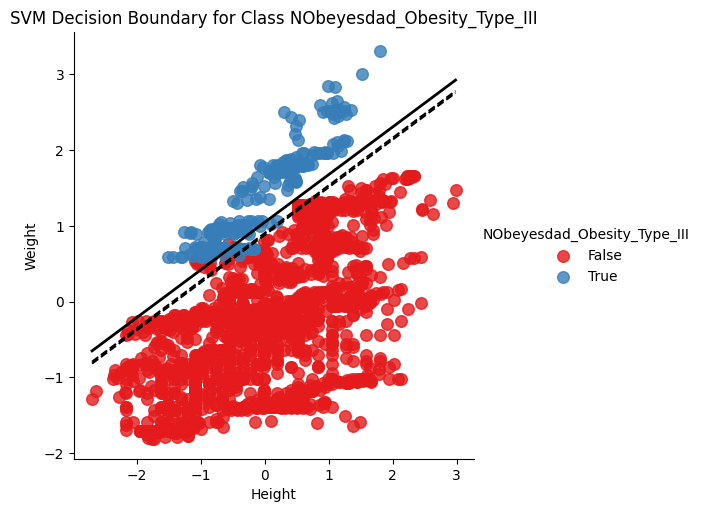

In [40]:
for obesity_class in classes:
    y2 = df2[obesity_class]
    X2_train, X2_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, stratify=y, random_state=42)

    linear_model = svm.SVC(kernel='linear')
    linear_model.fit(X2_train, y2_train)

    # Getting the separating hyperplane
    w = linear_model.coef_[0]
    a = -w[0] / w[1]
    xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    yy = a * xx - (linear_model.intercept_[0]) / w[1]

    # Plotting the parallels to the separating hyperplane that pass through the support vectors
    b = linear_model.support_vectors_[0]
    yy_down = a * xx + (b[1] - a * b[0])
    b = linear_model.support_vectors_[-1]
    yy_up = a * xx + (b[1] - a * b[0])

    # Displaying margins and support vectors
    sns.lmplot(x='Height', y='Weight', data=df2, hue=obesity_class, palette='Set1', fit_reg=False, scatter_kws={"s": 70})
    plt.plot(xx, yy, linewidth=2, color='black')
    plt.plot(xx, yy_down, 'k--')
    plt.plot(xx, yy_up, 'k--')
    plt.scatter(linear_model.support_vectors_[:, 0], linear_model.support_vectors_[:, -1],
                s=80, facecolors='none');
    plt.title(f"SVM Decision Boundary for Class {obesity_class}")

# DNN

In [41]:
#Building the DNN
def build_model(nn, nl):
    fn = 2
    cn = 6
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(fn,))])
    for _ in range(nl):
        model.add(tf.keras.layers.Dense(nn, activation='relu'))
        nn //= 2
    model.add(tf.keras.layers.Dense(cn, activation='softmax'))
    # Compiling
    model.compile(
        optimizer="adam",
        loss="SparseCategoricalCrossentropy",
        metrics=["accuracy"])
    return model

In [42]:
# Defining Hyperparameters with various values
nurone_numbers = [128,256,512]
batch_sizes = [32,64]
num_layers_list = [2, 3]
best_val_accuracy = 0.0
best_params = {}
results = []

# Experimenting Hyperparameter combinations and tracking the best accuracy
for n in nurone_numbers:
    for batch_size in batch_sizes:
        for nl in num_layers_list:
            print(n,batch_size,nl)
            model = build_model(n, nl)
            history = model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=15,
                batch_size=batch_size,
                verbose=1)
            results.append({
                'units': n,
                'batch_size': batch_size,
                '# hidden layers': nl,
                'val_accuracy': history.history['val_accuracy']})
            val_accuracy = history.history['val_accuracy'][-1]
            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_params = {'units': n, 'batch_size': batch_size, '# hidden layers': nl}

print("Best hyperparameters:", best_params)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


128 32 2
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.4113 - loss: 1.6281 - val_accuracy: 0.6525 - val_loss: 1.1525
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6695 - loss: 1.0385 - val_accuracy: 0.7730 - val_loss: 0.7974
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7801 - loss: 0.7522 - val_accuracy: 0.8038 - val_loss: 0.5751
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8376 - loss: 0.5370 - val_accuracy: 0.8936 - val_loss: 0.4248
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8725 - loss: 0.3981 - val_accuracy: 0.9338 - val_loss: 0.3261
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9056 - loss: 0.3207 - val_accuracy: 0.9409 - val_loss: 0.2631
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9358 - loss: 0.2551 - val_accuracy: 0.9338 - val_loss: 0.2308
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9416 - loss: 0.2164 - val_accuracy: 0.9385 -

In [43]:
# Evaluating the model performance
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:", '\n', cm)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Confusion Matrix: 
 [[ 54   0   0   0   0   0]
 [  9  49   0   0   0   0]
 [  0   0  70   0   0   0]
 [  0   0   4  56   0   0]
 [  0   0   0   5  60   0]
 [  0   3   0   0   0 113]]


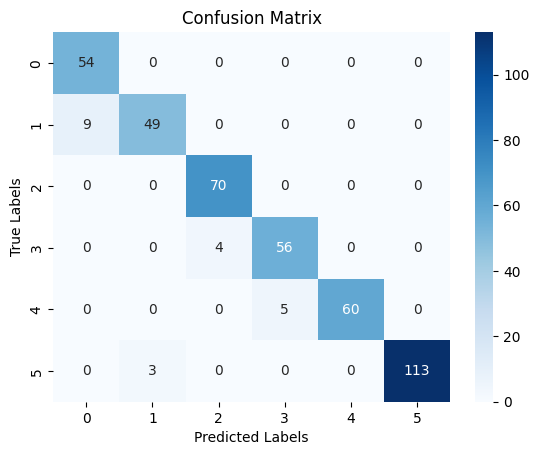

In [44]:
# Plotting Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [45]:
# Getting statistical summaries
training_accuracy = history.history['accuracy']
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')
report = classification_report(y_test, y_pred_classes)

print("Training Accuracy:", training_accuracy)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Classification Report:", report)

Training Accuracy: [0.5912322402000427, 0.7606635093688965, 0.8850710988044739, 0.9271327257156372, 0.9295023679733276, 0.9478672742843628, 0.953199028968811, 0.9508293867111206, 0.9472748637199402, 0.9537914395332336, 0.9537914395332336, 0.9603080749511719, 0.9626777172088623, 0.9597156643867493, 0.950236976146698]
Precision: 0.9533
Recall: 0.9504
F1-Score: 0.9503
Classification Report:               precision    recall  f1-score   support

           0       0.86      1.00      0.92        54
           1       0.94      0.84      0.89        58
           2       0.95      1.00      0.97        70
           3       0.92      0.93      0.93        60
           4       1.00      0.92      0.96        65
           5       1.00      0.97      0.99       116

    accuracy                           0.95       423
   macro avg       0.94      0.95      0.94       423
weighted avg       0.95      0.95      0.95       423



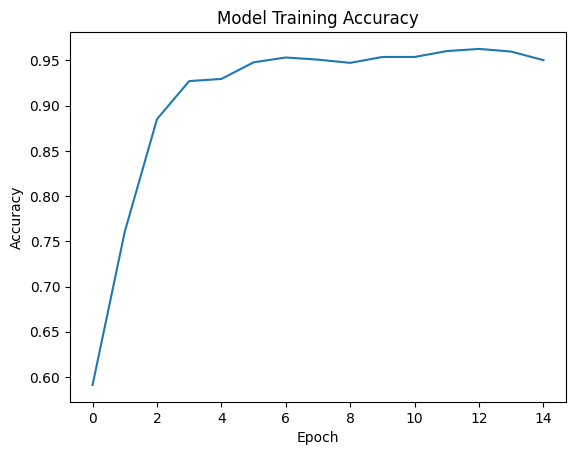

In [46]:
# Plotting training accuracy
plt.plot(training_accuracy)
plt.title('Model Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()


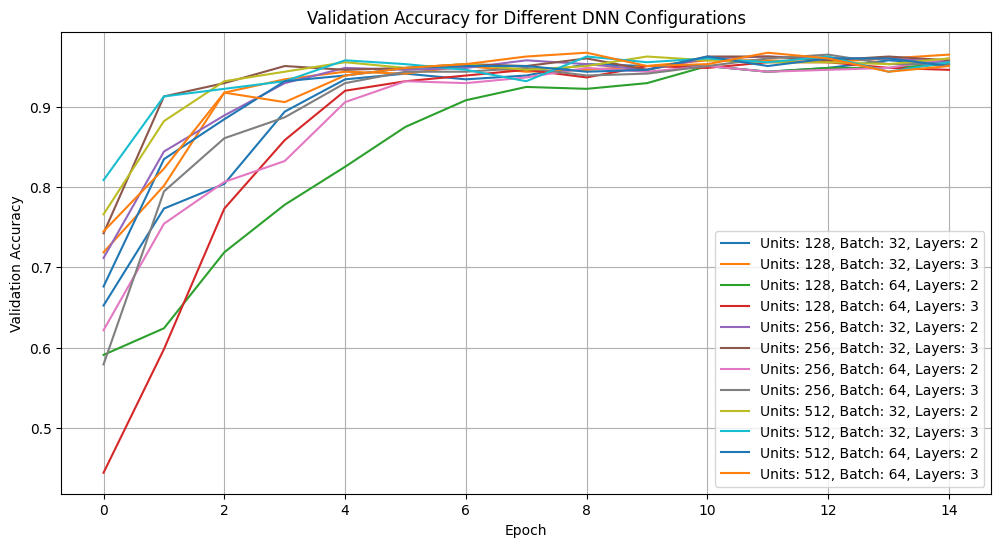

In [47]:
# Plotting validation aacuracies
plt.figure(figsize=(12, 6))

for result in results:
    label = f"Units: {result['units']}, Batch: {result['batch_size']}, Layers: {result['# hidden layers']}"
    plt.plot(result['val_accuracy'], label=label)

plt.title('Validation Accuracy for Different DNN Configurations')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
